# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith('hte-and-targeting"'):
    os.chdir('..')

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [5]:
from core.variables import *
from core.dgp import MultipleSegmentsTreatmentSelection as MultipleSegments
import core.treatment_selection_multiple_segments as tsms

# DGP

In [6]:
dgp_params = {
    'delta_te': 0.05, 'n_segments': 2, 'n_treatments': 2, 'noise_std': 1.0
}

dgp = MultipleSegments(**dgp_params)
segment_arr, treatment_arr, outcome_arr = dgp.sample_treatment(1000, seed=0)

# Demand Model

In [7]:
emp_te_arr = tsms.estimate_te(segment_arr, treatment_arr, outcome_arr, dgp.n_segments, dgp.n_treatments)

for segment_idx in range(dgp.n_segments):
    for treatment_idx in range(dgp.n_treatments):
        print(f'Segment {segment_idx}, Treatment {treatment_idx}: True TE = {dgp.te_arr[segment_idx, treatment_idx]:.4f}, Estimated TE = {emp_te_arr[segment_idx, treatment_idx]:.4f}')


Segment 0, Treatment 0: True TE = 0.0500, Estimated TE = 0.0571
Segment 0, Treatment 1: True TE = 0.1000, Estimated TE = 0.1518
Segment 1, Treatment 0: True TE = 0.1000, Estimated TE = 0.0689
Segment 1, Treatment 1: True TE = 0.1500, Estimated TE = 0.2307


# Optimization

In [8]:
plugin_decision, plugin_val_est = tsms.optimize(te_arr=emp_te_arr, budget=1)
true_plugin_val = tsms.obj_func(te_arr=dgp.te_arr, decision=plugin_decision)

print(f'Plugin Decision: {plugin_decision}')
print(f'Estimated Targeting Value: {plugin_val_est:.2f}')
print(f'True Targeting Value: {true_plugin_val:.2f}')

print()
print(f"Winner's curse (measured in MPE): {100 * (plugin_val_est - true_plugin_val)/true_plugin_val:.2f}%")

NameError: name 'opt_decision' is not defined

# Winner's Curse

In [11]:
operations_params = {'budget': 1}

# dgp params
dgp_params = {
    'delta_te': 0.05, 'n_segments': 2, 'n_treatments': 2, 'noise_std': 1.0
}

# data params
data_params = {'sample_size': 200}

# experiment params
experiment_params = {'n_experiments': 5000, 'stats': 'mean'}

# estimators
estimators_dict = {} 

result_records = tsms.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

# analysis
emp_wc_arr = np.array([result['plugin_wc'] for result in result_records])
emp_wc_pct_arr = 100 * np.array([result['plugin_wc_pct'] for result in result_records])

avg_wc = np.mean(emp_wc_arr)
avg_wc_pct = np.mean(emp_wc_pct_arr)
se_wc = np.std(emp_wc_arr) / np.sqrt(data_params['sample_size'])
se_wc_pct = np.std(emp_wc_pct_arr) / np.sqrt(data_params['sample_size'])

print(f'Average Empirical Winner\'s Curse: {avg_wc:.4f} ± {se_wc:.4f}')
print(f'Average Empirical Winner\'s Curse (percentage): {avg_wc_pct:.2f}% ± {se_wc_pct:.2f}%')


Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4009 tasks      | elapsed:    0.1s


Average Empirical Winner's Curse: 0.1423 ± 0.0075
Average Empirical Winner's Curse (percentage): 154.89% ± 10.24%


[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.2s finished


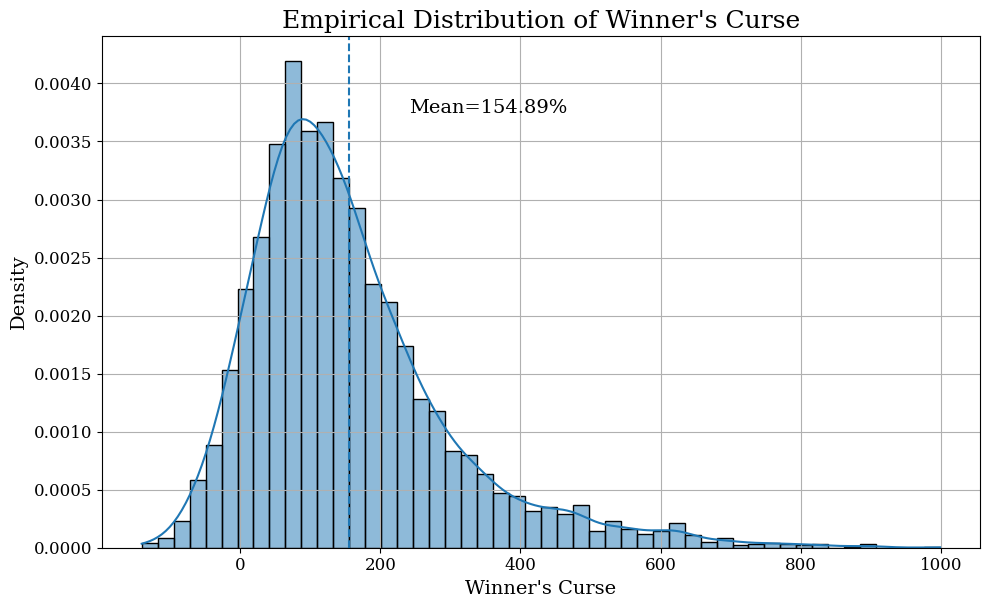

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_pct_arr, bins=50, kde=True, stat='density', ax=ax, color='C0')
ax.axvline(emp_wc_pct_arr.mean(), color='C0', linestyle='--')
ax.annotate(
    f"Mean={emp_wc_pct_arr.mean():.2f}%", 
    xy=(0.35, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)

ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Estimating Winner's Curse

In [13]:
dgp = MultipleSegments(**dgp_params) 
segment_arr, treatment_arr, outcome_arr = dgp.sample_treatment(**data_params, seed=0)

## Standard Bootstrap

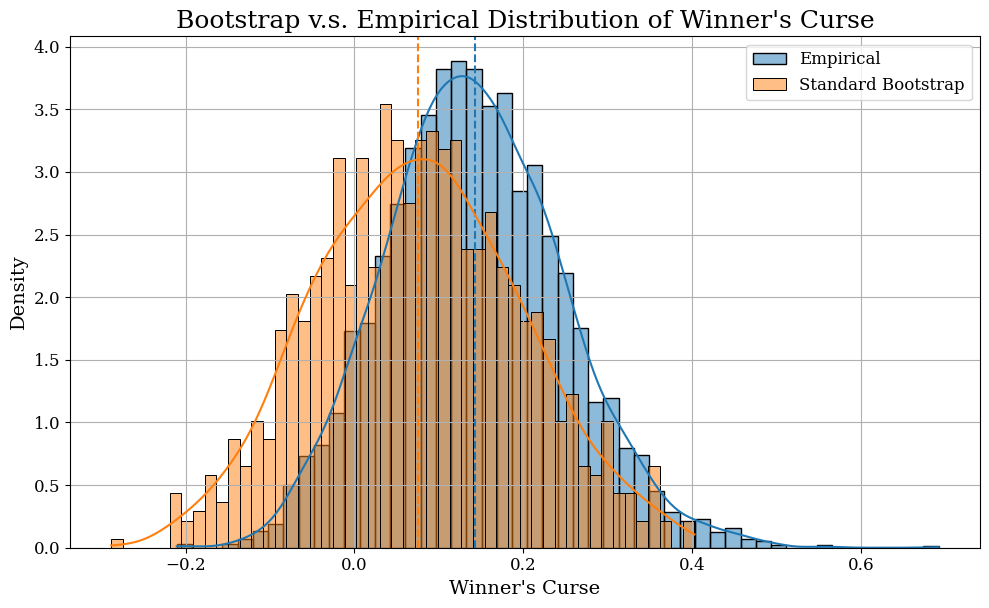

In [14]:
# generate bootstrap distribution
boot_wc_dstn_arr = tsms.get_wc_boot_dstn(
    segments=segment_arr, treatments=treatment_arr, outcomes=outcome_arr,
    n_segments=dgp.n_segments, n_treatments=dgp.n_treatments,
    **operations_params, n_bootstraps=1000, n_jobs=-1, verbose=False, 
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_arr, bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_wc_arr.mean(), color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C1', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 3893 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.2s finished


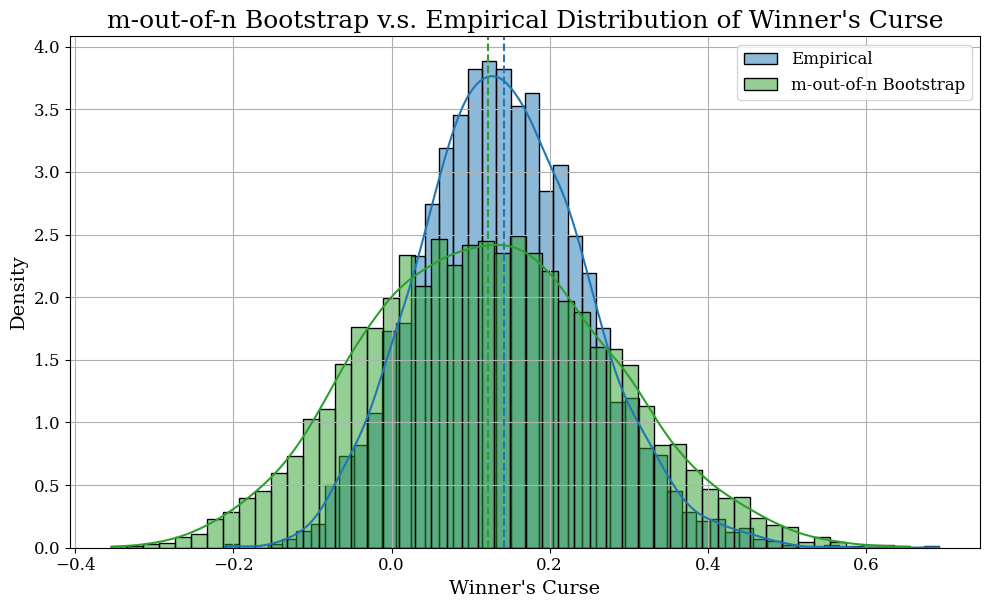

In [15]:
# generate bootstrap distribution
boot_wc_dstn_arr = tsms.get_wc_m_out_of_n_boot_dstn(
    segments=segment_arr, treatments=treatment_arr, outcomes=outcome_arr,
    n_segments=dgp.n_segments, n_treatments=dgp.n_treatments,
    **operations_params, power=0.9, n_bootstraps=5000, n_jobs=-1, verbose=False, 
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_arr, bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_wc_arr.mean(), color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C2', linestyle='--')

ax.set_title("m-out-of-n Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap


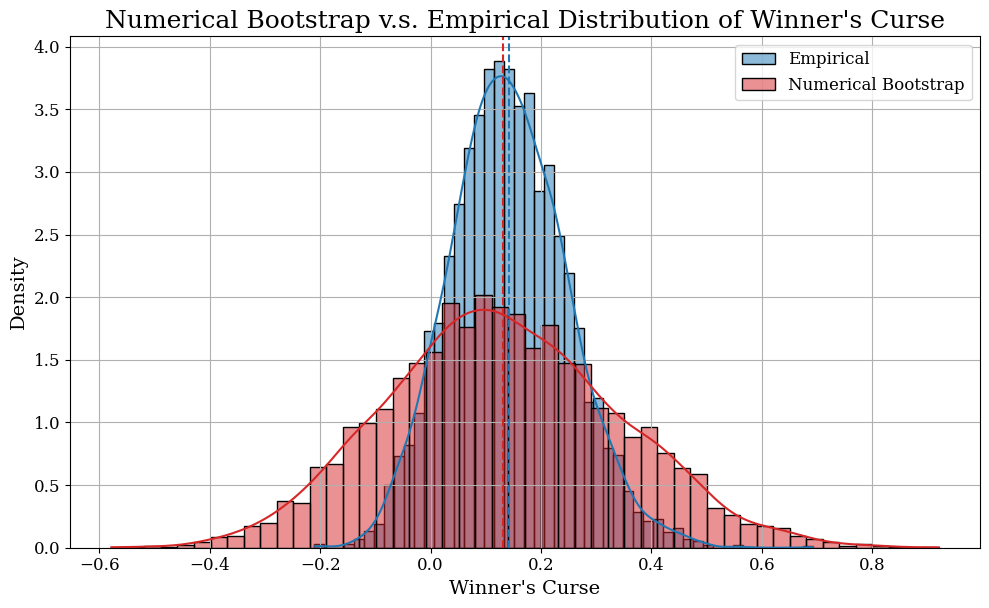

In [16]:
# generate bootstrap distribution
boot_wc_dstn_arr = tsms.get_wc_num_boot_dstn(
    segments=segment_arr, treatments=treatment_arr, outcomes=outcome_arr,
    n_segments=dgp.n_segments, n_treatments=dgp.n_treatments,
    **operations_params, power=-0.4, n_bootstraps=5000, n_jobs=-1, verbose=False, 
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_arr, bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_wc_arr.mean(), color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C3', label='Numerical Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C3', linestyle='--')

ax.set_title("Numerical Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Bias Correction

In [17]:
operations_params = {'budget': 1}

# dgp params
dgp_params = {
    'delta_te': 0.05, 'n_segments': 2, 'n_treatments': 2, 'noise_std': 1.0
}

# data params
data_params = {'sample_size': 500}

# experiment params
experiment_params = {'n_experiments': 1000, 'stats': 'mean'}

# estimators
estimators_dict = {
    'standard_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
            'n_jobs': 1,
        }
    }, 
    'mn_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95, 'n_jobs': 1,
        }
    }, 
    'num_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'numerical', 
            'power': - 0.45, 'n_jobs': 1,
        }
    }
}

In [18]:
result_records = tsms.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)


Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   22.9s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   43.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   57.5s finished


In [19]:
wc_df = pd.DataFrame.from_records({
    f'{name}':  np.array([record[f'{name}_wc'] for record in result_records])
    for name in ['plugin'] + list(estimators_dict.keys())
})

for estimator in ['plugin'] + list(estimators_dict.keys()):
    avg_wc_pct = np.mean(wc_df[estimator])
    se_wc_pct = np.std(wc_df[estimator]) / np.sqrt(data_params['sample_size'])

    print(f'Winner\'s Curse of {estimator}: {avg_wc_pct:.4f} ({se_wc_pct:.4f})')

Winner's Curse of plugin: 0.0832 (0.0029)
Winner's Curse of standard_bootstrap: 0.0217 (0.0035)
Winner's Curse of mn_bootstrap: 0.0052 (0.0035)
Winner's Curse of num_bootstrap: -0.0006 (0.0037)


In [20]:
wc_pct_df = pd.DataFrame.from_records({
    f'{name}': 100 * np.array([record[f'{name}_wc_pct'] for record in result_records])
    for name in ['plugin'] + list(estimators_dict.keys())
})

for estimator in ['plugin'] + list(estimators_dict.keys()):
    avg_wc_pct = np.mean(wc_pct_df[estimator])
    se_wc_pct = np.std(wc_pct_df[estimator]) / np.sqrt(data_params['sample_size'])

    print(f'Winner\'s Curse MPE of {estimator}: {avg_wc_pct:.2f}% ({se_wc_pct:.2f}%)')

Winner's Curse MPE of plugin: 83.88% (3.67%)
Winner's Curse MPE of standard_bootstrap: 24.78% (3.46%)
Winner's Curse MPE of mn_bootstrap: 9.27% (3.38%)
Winner's Curse MPE of num_bootstrap: 3.33% (3.54%)


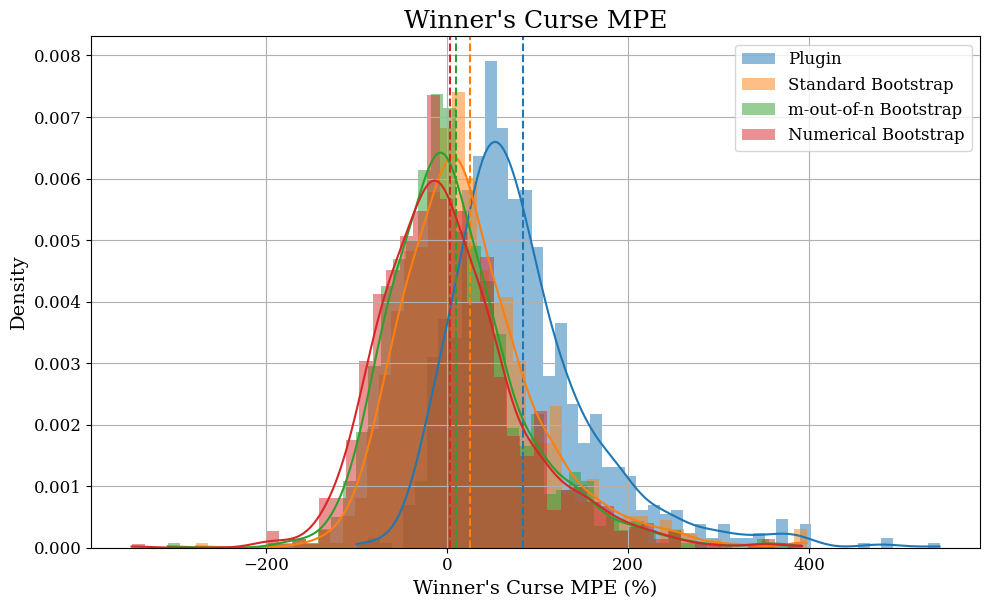

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# winner's curse MPE
for idx, estimator in enumerate(['plugin', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']):
    sns.histplot(
        wc_pct_df, x=estimator, bins=50, kde=True, stat='density', ax=ax, color=f'C{idx}', edgecolor=None, 
        label=model_label_map[estimator]
    )
    ax.axvline(wc_pct_df[estimator].mean(), color=f'C{idx}', linestyle='--')

ax.set_title('Winner\'s Curse MPE', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse MPE (%)', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
# plt.savefig('figures/case1-bias-correction.png')
plt.show()